In [15]:
import pandas as pd

# Load the dataset
df = pd.read_excel(r"C:\Users\KARTHIKEYA\Desktop\COAL Consumption.xlsx")

# Rename columns for Prophet
df.rename(columns={"Year": "ds", "Coal Consumption - TWh": "y"}, inplace=True)

# Convert 'ds' to datetime format
df['ds'] = pd.to_datetime(df['ds'], format='%Y')

# Filter data for a specific country/entity (e.g., "Africa")
entity = "Africa"
df_entity = df[df["Entity"] == entity]

In [16]:
from prophet import Prophet

# Initialize and fit the model
model = Prophet()
model.fit(df_entity)

01:10:09 - cmdstanpy - INFO - Chain [1] start processing
01:10:09 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
# Create a future dataframe for the next 5 years
future = model.make_future_dataframe(periods=11, freq='Y')

# Predict
forecast = model.predict(future)

# Extract predictions for the next 5 years
forecast_next_5_years = forecast[['ds', 'yhat']].tail(5)
print(forecast_next_5_years)

           ds         yhat
54 2018-12-31  1377.818841
55 2019-12-31  1439.651675
56 2020-12-31  1344.143968
57 2021-12-31  1387.944222
58 2022-12-31  1440.793067


C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


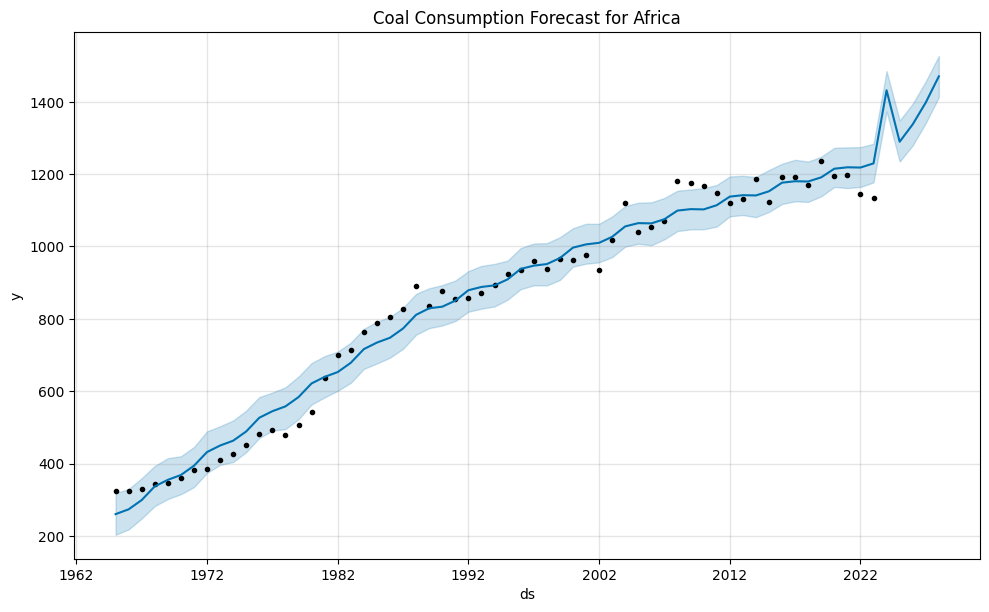

In [18]:
import matplotlib.pyplot as plt

model.plot(forecast)
plt.title(f"Coal Consumption Forecast for {entity}")
plt.show()

**FINE TUNING THE MODEL**

In [19]:
model_finetuned = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.5  # Adjust sensitivity to trend changes
)
model_finetuned.fit(df_entity)

01:10:16 - cmdstanpy - INFO - Chain [1] start processing
01:10:16 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future_finetuned = model_finetuned.make_future_dataframe(periods=11, freq='Y')
forecast_finetuned = model_finetuned.predict(future_finetuned)

# Extract predictions for the next 5 years
forecast_finetuned_next_5_years = forecast_finetuned[['ds', 'yhat']].tail(5)
print(forecast_finetuned_next_5_years)

           ds          yhat
65 2029-12-31  44233.347733
66 2030-12-31  44005.164516
67 2031-12-31  43718.367126
68 2032-12-31  44651.456988
69 2033-12-31  44482.206727


C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [21]:
comparison = pd.DataFrame({
    "Year": forecast_next_5_years['ds'],
    "Initial Prediction": forecast_next_5_years['yhat'],
    "Fine-Tuned Prediction": forecast_finetuned_next_5_years['yhat']
})
print(comparison)

         Year  Initial Prediction  Fine-Tuned Prediction
59 2023-12-31         1431.637771            1364.945687
60 2024-12-31         1289.401030            1222.542888
61 2025-12-31         1337.579583            1261.581333
62 2026-12-31         1397.872828            1311.901194
63 2027-12-31         1470.194209            1373.423001


**REPEATING FOR ALL ENTITIES**

In [28]:
# Get unique entities
entities = df["Entity"].unique()

# Initialize a list to store results
results = []

for entity in entities:
    df_entity = df[df["Entity"] == entity]

    # Train initial model
    model = Prophet()
    model.fit(df_entity)
    future = model.make_future_dataframe(periods=5, freq='Y')
    forecast = model.predict(future)
    forecast_initial = forecast[['ds', 'yhat']].tail(5)

    # Train fine-tuned model
    model_finetuned = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.5)
    model_finetuned.fit(df_entity)
    future_finetuned = model_finetuned.make_future_dataframe(periods=5, freq='Y')
    forecast_finetuned = model_finetuned.predict(future_finetuned)
    forecast_finetuned = forecast_finetuned[['ds', 'yhat']].tail(5)

    # Combine results
    comparison = pd.DataFrame({
        "Entity": [entity] * 5,
        "Year": forecast_initial['ds'],
        "Initial Prediction": forecast_initial['yhat'],
        "Fine-Tuned Prediction": forecast_finetuned['yhat']
    })
    results.append(comparison)

# Combine all results into one DataFrame
final_results = pd.concat(results, ignore_index=True)
print(final_results)

01:14:37 - cmdstanpy - INFO - Chain [1] start processing
01:14:37 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
01:14:38 - cmdstanpy - INFO - Chain [1] start processing
01:14:38 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
01:14:38 - cmdstanpy - INFO - Chain [1] start processing
01:14:38 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' inste

      Entity       Year  Initial Prediction  Fine-Tuned Prediction
0     Africa 2023-12-31         1431.637771                    NaN
1     Africa 2024-12-31         1289.401030                    NaN
2     Africa 2025-12-31         1337.579583                    NaN
3     Africa 2026-12-31         1397.872828                    NaN
4     Africa 2027-12-31         1470.194209                    NaN
...      ...        ...                 ...                    ...
1139   World 2029-12-31        53110.173567           44233.347733
1140   World 2030-12-31        53948.698147           44005.164516
1141   World 2031-12-31        54826.641013           43718.367126
1142   World 2032-12-31        55240.400957           44651.456988
1143   World 2033-12-31        56039.263664           44482.206727

[1144 rows x 4 columns]


C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [27]:
final_results.to_csv("coal_consumption_predictions_using_LSTM.csv", index=False)

In [23]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel(r"C:\Users\KARTHIKEYA\Desktop\COAL Consumption.xlsx")
df.rename(columns={"Year": "ds", "Coal Consumption - TWh": "y"}, inplace=True)
df['ds'] = pd.to_datetime(df['ds'], format='%Y')

# Filter for Africa
entity = "Africa"
df_africa = df[df["Entity"] == entity].copy()

# Train-test split
train_df = df_africa[df_africa['ds'].dt.year <= 2012]
test_df = df_africa[(df_africa['ds'].dt.year >= 2013) & (df_africa['ds'].dt.year <= 2023)]

# Prophet model
model = Prophet()
model.fit(train_df)

# Create future dates from 2013 to 2023
future = model.make_future_dataframe(periods=11, freq='Y')  # 2013–2023 is 11 years
forecast = model.predict(future)

# Extract predictions for 2013–2023
forecast_test = forecast[forecast['ds'].isin(test_df['ds'])][['ds', 'yhat']].reset_index(drop=True)

# Merge predictions with actual values
results = test_df[['ds', 'y']].reset_index(drop=True)
results['yhat'] = forecast_test['yhat']

# Evaluation metrics
mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mape = np.mean(np.abs((results['y'] - results['yhat']) / results['y'])) * 100

# Output metrics
print("Evaluation Metrics (2013–2023):")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(results['ds'], results['y'], label='Actual', marker='o')
plt.plot(results['ds'], results['yhat'], label='Predicted', marker='x')
plt.title(f"Coal Consumption Forecast vs Actuals (Africa, 2013–2023)")
plt.xlabel("Year")
plt.ylabel("Coal Consumption (TWh)")
plt.legend()
plt.grid(True)
plt.show()


01:12:37 - cmdstanpy - INFO - Chain [1] start processing
01:12:38 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


ValueError: Input contains NaN.